In [1]:
import random
random.seed(42)

In [2]:
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
from torch.nn.utils.parametrize import remove_parametrizations
import seaborn as sns
import re

In [55]:
import os
import pandas as pd
import numpy as np
import shutil
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from optuna.importance import get_param_importances
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import lightgbm as lgb
import optuna

import math

In [4]:
sns.set_theme(style="whitegrid", palette="rocket")

In [5]:
df=pd.read_csv('/kaggle/input/datasets/annarechkalova/processed-sepsis-dataset/processed_dataset_v2.psv', sep="|")
importance_df_wo_windows=pd.read_csv('/kaggle/input/datasets/annarechkalova/tcn-importance-wo-windows/importance_df_wo_windows_tcn.csv')
top_features_wo_windows = importance_df_wo_windows[importance_df_wo_windows['Importance'] > 0]
df_col = ['id', 'SepsisLabel']
df_col += top_features_wo_windows['Feature'].tolist()
df = df[df_col]

In [6]:
df = df.sort_values(['id', 'ICULOS'])
ids = df['id'].unique()

In [7]:
df_col = [c for c in df_col if c not in ['id', 'SepsisLabel']
and not re.search(r'_(Min|Max|Mean|Std|Freq)_\d+h$', c)]

In [8]:
df_col_without_missing = [c for c in df_col if not c.endswith('_missing')]

scaled_df = df.copy()
scaler = StandardScaler()
scaler.fit(scaled_df[df_col_without_missing])

scaled_df[df_col_without_missing] = scaled_df[df_col_without_missing].astype(float)
scaled_df.loc[:, df_col_without_missing] = scaler.transform(
    scaled_df[df_col_without_missing]
)
scaled_df[df_col_without_missing] = scaled_df[df_col_without_missing].fillna(0)

In [9]:
df_col_without_missing

['ICULOS',
 'Temp',
 'WBC',
 'DBP',
 'HR',
 'Platelets',
 'BUN',
 'FiO2',
 'pH',
 'Creatinine',
 'ShockIndex',
 'Potassium',
 'O2Sat',
 'Bilirubin_total',
 'Hct',
 'Lactate',
 'Glucose',
 'Chloride',
 'Hgb',
 'Gender',
 'Unit2',
 'Resp',
 'Phosphate',
 'Unit1',
 'Calcium',
 'AST',
 'PTT',
 'SBP',
 'MAP']

In [10]:
pd.set_option('display.max_rows', 100)

In [11]:
scaled_df[scaled_df['id'] == 'p000161']

,id,SepsisLabel,ICULOS,Temp,WBC,EtCO2_missing,DBP,FiO2_missing,SBP_missing,HR,...,PTT,Calcium_missing,SBP,Bilirubin_total_missing,BUN_missing,Hgb_missing,MAP,Fibrinogen_missing,HCO3_missing,WBC_missing
5973,p000161,0,-0.896212,0.000000,0.000000,1,0.000000,1,1,0.000000,...,0.0,1,0.000000,1,1,1,0.000000,1,1,1
5974,p000161,0,-0.861736,0.000000,0.000000,1,2.401802,1,0,-0.251846,...,0.0,1,1.566615,1,1,1,1.185911,1,1,1
5975,p000161,0,-0.827259,0.788767,0.000000,1,1.693331,1,0,-0.079085,...,0.0,1,0.747953,1,1,1,0.268956,1,1,1
5976,p000161,0,-0.792783,0.788767,0.000000,1,2.543496,0,0,-0.136672,...,0.0,1,1.265002,1,0,1,0.941390,1,0,1
5977,p000161,0,-0.758307,1.415237,0.000000,1,1.835026,1,0,-0.194259,...,0.0,1,0.489428,1,0,1,0.452347,1,0,1
5978,p000161,0,-0.723830,1.415237,0.000000,1,1.055708,0,0,-0.367020,...,0.0,1,-0.027622,1,1,1,0.024434,1,1,1
5979,p000161,0,-0.689354,1.415237,0.000000,1,1.055708,1,0,-0.194259,...,0.0,1,0.144728,1,1,1,-0.342348,1,1,1
5980,p000161,0,-0.654878,1.415237,0.000000,1,0.984860,1,0,-0.251846,...,0.0,1,0.230903,1,1,1,-0.036696,1,1,1
5981,p000161,0,-0.620401,1.484845,0.000000,1,0.807743,0,0,-0.280639,...,0.0,1,-0.006078,1,1,1,-0.189522,1,1,1
5982,p000161,0,-0.585925,1.484845,0.000000,1,0.630625,1,0,-0.367020,...,0.0,1,-0.243059,1,1,1,0.207825,1,1,1


# TCN

In [12]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = dilation * (kernel_size - 1)
        self.conv = weight_norm(nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation))

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, dropout=0.2):
        super(ResidualBlock, self).__init__()
        
        self.optional_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

        self.causal_conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout)

        self.causal_conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout)

        self.residual = nn.Sequential(self.causal_conv1, self.relu1, self.dropout1, 
                                      self.causal_conv2, self.relu2, self.dropout2)

        # self.relu = nn.ReLU()

    def forward(self, x):
        res = self.residual(x)
        x_conv = self.optional_conv(x) if self.optional_conv is not None else x
        # out = self.relu(x_conv + res)
        out = x_conv + res
        return out

In [14]:
class TCN(nn.Module):
    def __init__(self, in_channels, out_channels, levels, kernel_size, dropout=0.2):
        super(TCN, self).__init__()
        layers = []
        for i in range(levels):
            dilation = 2 ** i
            now_num_channels = in_channels if i == 0 else out_channels[i - 1]
            now_out_channels = out_channels[i]
            layers += [ResidualBlock(now_num_channels, now_out_channels, kernel_size, dilation, dropout)]

        self.tcn = nn.Sequential(*layers)
        self.linear = nn.Linear(out_channels[-1], 1)

    def forward(self, x, return_embeddings=False):
        x = self.tcn(x)
        if return_embeddings:            
            return x
        x = x.transpose(1, 2) 
        x = self.linear(x)
        return x

# WinTSR

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
params = {'kernel_size': 3,
 'out_channels': [64, 64, 128, 128],
 'dropout': 0.1,
 'lr': 0.0001,
 'pos_weight': 12}

In [18]:
model_tcn = TCN(
        in_channels=54, 
        out_channels=params['out_channels'], 
        levels=len(params['out_channels']), 
        kernel_size=params['kernel_size'], 
        dropout=params['dropout']
    ).to(device)

state_dict = torch.load('/kaggle/input/models/annarechkalova/tcn-54-features/pytorch/default/1/tcn_model_winner.pth', map_location=device)

model_tcn.load_state_dict(state_dict)

model_tcn.eval()

TCN(
  (tcn): Sequential(
    (0): ResidualBlock(
      (optional_conv): Conv1d(54, 64, kernel_size=(1,), stride=(1,))
      (causal_conv1): CausalConv1d(
        (conv): ParametrizedConv1d(
          54, 64, kernel_size=(3,), stride=(1,), padding=(2,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
      )
      (relu1): ReLU()
      (dropout1): Dropout(p=0.1, inplace=False)
      (causal_conv2): CausalConv1d(
        (conv): ParametrizedConv1d(
          64, 64, kernel_size=(3,), stride=(1,), padding=(2,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
      )
      (relu2): ReLU()
      (dropout2): Dropout(p=0.1, inplace=False)
      (residual): Sequential(
        (0): CausalConv1d(
          (conv): ParametrizedConv1d(
            54, 64, kernel_size=(3,), stride=(1,), pad

In [19]:
def wintsr(model, patient_data, device, mask_value=0.0):
    model.eval()
    patient_input = patient_data.unsqueeze(0).to(device)
    n_features, n_timesteps = patient_data.shape

    with torch.no_grad():
        baseline_output = model(patient_input).squeeze()
        baseline_probs = torch.sigmoid(baseline_output).cpu().numpy()

    time_relevance = np.zeros(n_timesteps)
    for t in range(n_timesteps):
        x_masked = patient_input.clone()
        x_masked[0, :, t] = mask_value
        with torch.no_grad():
            output = model(x_masked).squeeze()
            probs = torch.sigmoid(output).cpu().numpy()
        time_relevance[t] = np.sum(np.abs(baseline_probs - probs))

    time_relevance = (time_relevance - time_relevance.min()) / (time_relevance.max() - time_relevance.min() + 1e-8)

    feature_relevance = np.zeros((n_features, n_timesteps))
    for f in range(n_features):
        for t in range(n_timesteps):
            x_masked = patient_input.clone()
            x_masked[0, f, t] = mask_value
            with torch.no_grad():
                output = model(x_masked).squeeze()
                probs = torch.sigmoid(output).cpu().numpy()
            feature_relevance[f, t] = np.abs(baseline_probs[t] - probs[t])
            # feature_relevance[f, t] = baseline_probs[t] - probs[t]

    importance_map = feature_relevance * time_relevance[np.newaxis, :]

    return importance_map, feature_relevance, time_relevance

In [53]:
colors_v1 = {
    'missingness': '#F1A208',
    'raw': '#052F5F',
}

def get_color_v1(feature_name):
    if '_missing' in feature_name:
        return colors_v1['missingness']
    else:
        return colors_v1['raw']

In [39]:
def plot_wintsr(importance_map, feature_names, patient_id="", top_k=None,
                show_missing=True, start_hour=1, filename=None):
    feature_names = list(feature_names)
    if not show_missing:
        idx = [i for i, n in enumerate(feature_names) if '_missing' not in n]
        importance_map = importance_map[idx]
        feature_names = [feature_names[i] for i in idx]
    mean_abs = np.abs(importance_map).mean(axis=1)
    top_idx = np.argsort(mean_abs)[::-1][:top_k]
    importance_map = importance_map[top_idx]
    feature_names = [feature_names[i] for i in top_idx]
    n_timesteps = importance_map.shape[1]
    hour_labels = list(range(start_hour, start_hour + n_timesteps))
    cell_height = 0.4
    fig_height = len(feature_names) * cell_height + 2
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'font.weight': 'normal',
        'axes.labelweight': 'normal'
    })
    fig, ax = plt.subplots(figsize=(20, fig_height), facecolor='white')
    sns.heatmap(importance_map, ax=ax,
                xticklabels=hour_labels, yticklabels=feature_names)
    ax.set_title(f'WinTSR Importance Map — Patient {patient_id}')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Features')
    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

In [57]:
def plot_wintsr_bar(importance_map, feature_names, hour, color_func, colors_dict,
                    patient_id="", top_k=15, show_missing=True, start_hour=1,
                    filename=None):
    feature_names = list(feature_names)
    hour_idx = hour - start_hour

    if not show_missing:
        idx = [i for i, n in enumerate(feature_names) if '_missing' not in n]
        importance_map = importance_map[idx]
        feature_names = [feature_names[i] for i in idx]

    hour_importance = importance_map[:, hour_idx]
    top_idx = np.argsort(hour_importance)[::-1][:top_k]
    top_names = [feature_names[i] for i in top_idx][::-1]
    top_values = hour_importance[top_idx][::-1]
    colors = [color_func(f) for f in top_names]

    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'font.weight': 'normal',
        'axes.labelweight': 'normal'
    })

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
    bars = ax.barh(top_names, top_values, color=colors,
                   edgecolor='#333333', linewidth=0.6)

    for bar, val in zip(bars, top_values):
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height() / 2,
                f'+{width:.3f}', va='center', ha='left', fontsize=9, color='black')

    xmax = ax.get_xlim()[1]
    ax.set_xlim(0, xmax + 0.01)
    ax.set_xlabel('Impact on sepsis probability', fontsize=11, labelpad=10, color='black')
    ax.set_ylabel('Features', fontsize=11, labelpad=5, color='black')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='both', colors='black', labelsize=10)
    ax.grid(True, axis='x', linestyle='-', color='black', alpha=0.08, linewidth=0.5)
    ax.set_axisbelow(True)

    legend = [Patch(color=v, label=k) for k, v in colors_dict.items()]
    ax.legend(handles=legend, loc='lower right', frameon=True,
              edgecolor='black', fontsize=9)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

In [24]:
patient_septic_df = scaled_df[scaled_df['id'] == 'p000161']
patient_non_septic_df = scaled_df[scaled_df['id'] == 'p000001']

In [25]:
patient_septic_features = torch.tensor(patient_septic_df[df_col].values.T, dtype=torch.float32)
patient_non_septic_features = torch.tensor(patient_non_septic_df[df_col].values.T, dtype=torch.float32)

In [34]:
def make_results_df_tcn(patient_id, model, scaled_df, df_col, threshold, device):
    patient_df = scaled_df[scaled_df['id'] == patient_id]
    features = torch.tensor(
        patient_df[df_col].values.T,
        dtype=torch.float32
    )
    with torch.no_grad():
        output = model(features.unsqueeze(0).to(device)).squeeze()
        probs = torch.sigmoid(output).cpu().numpy()
    preds = (probs >= threshold).astype(int)

    results = pd.DataFrame({
        'Real Label':  patient_df['SepsisLabel'].values.astype(int),
        'Probability': probs.round(4),
        'Prediction':  preds,
    })
    results.index = range(1, len(results) + 1)
    results.index.name = 'Hour'
    return results

In [35]:
threshold = 0.22

results_septic = make_results_df_tcn('p000161', model_tcn, scaled_df, df_col, threshold, device)
results_non_septic = make_results_df_tcn('p000001', model_tcn, scaled_df, df_col, threshold, device)

In [36]:
results_septic

,Real Label,Probability,Prediction
Hour,,,
1,0,0.1206,0
2,0,0.1010,0
3,0,0.0937,0
4,0,0.1294,0
5,0,0.1471,0
6,0,0.2388,1
7,0,0.2467,1
8,0,0.2275,1
9,0,0.2517,1


In [37]:
results_non_septic

,Real Label,Probability,Prediction
Hour,,,
1,0,0.1206,0
2,0,0.1353,0
3,0,0.1291,0
4,0,0.1700,0
5,0,0.2813,1
6,0,0.3232,1
7,0,0.3203,1
8,0,0.2547,1
9,0,0.2199,0


## Septic patient p000161

In [38]:
importance_map, feature_relevance, time_relevance = wintsr(model_tcn, patient_septic_features, device)

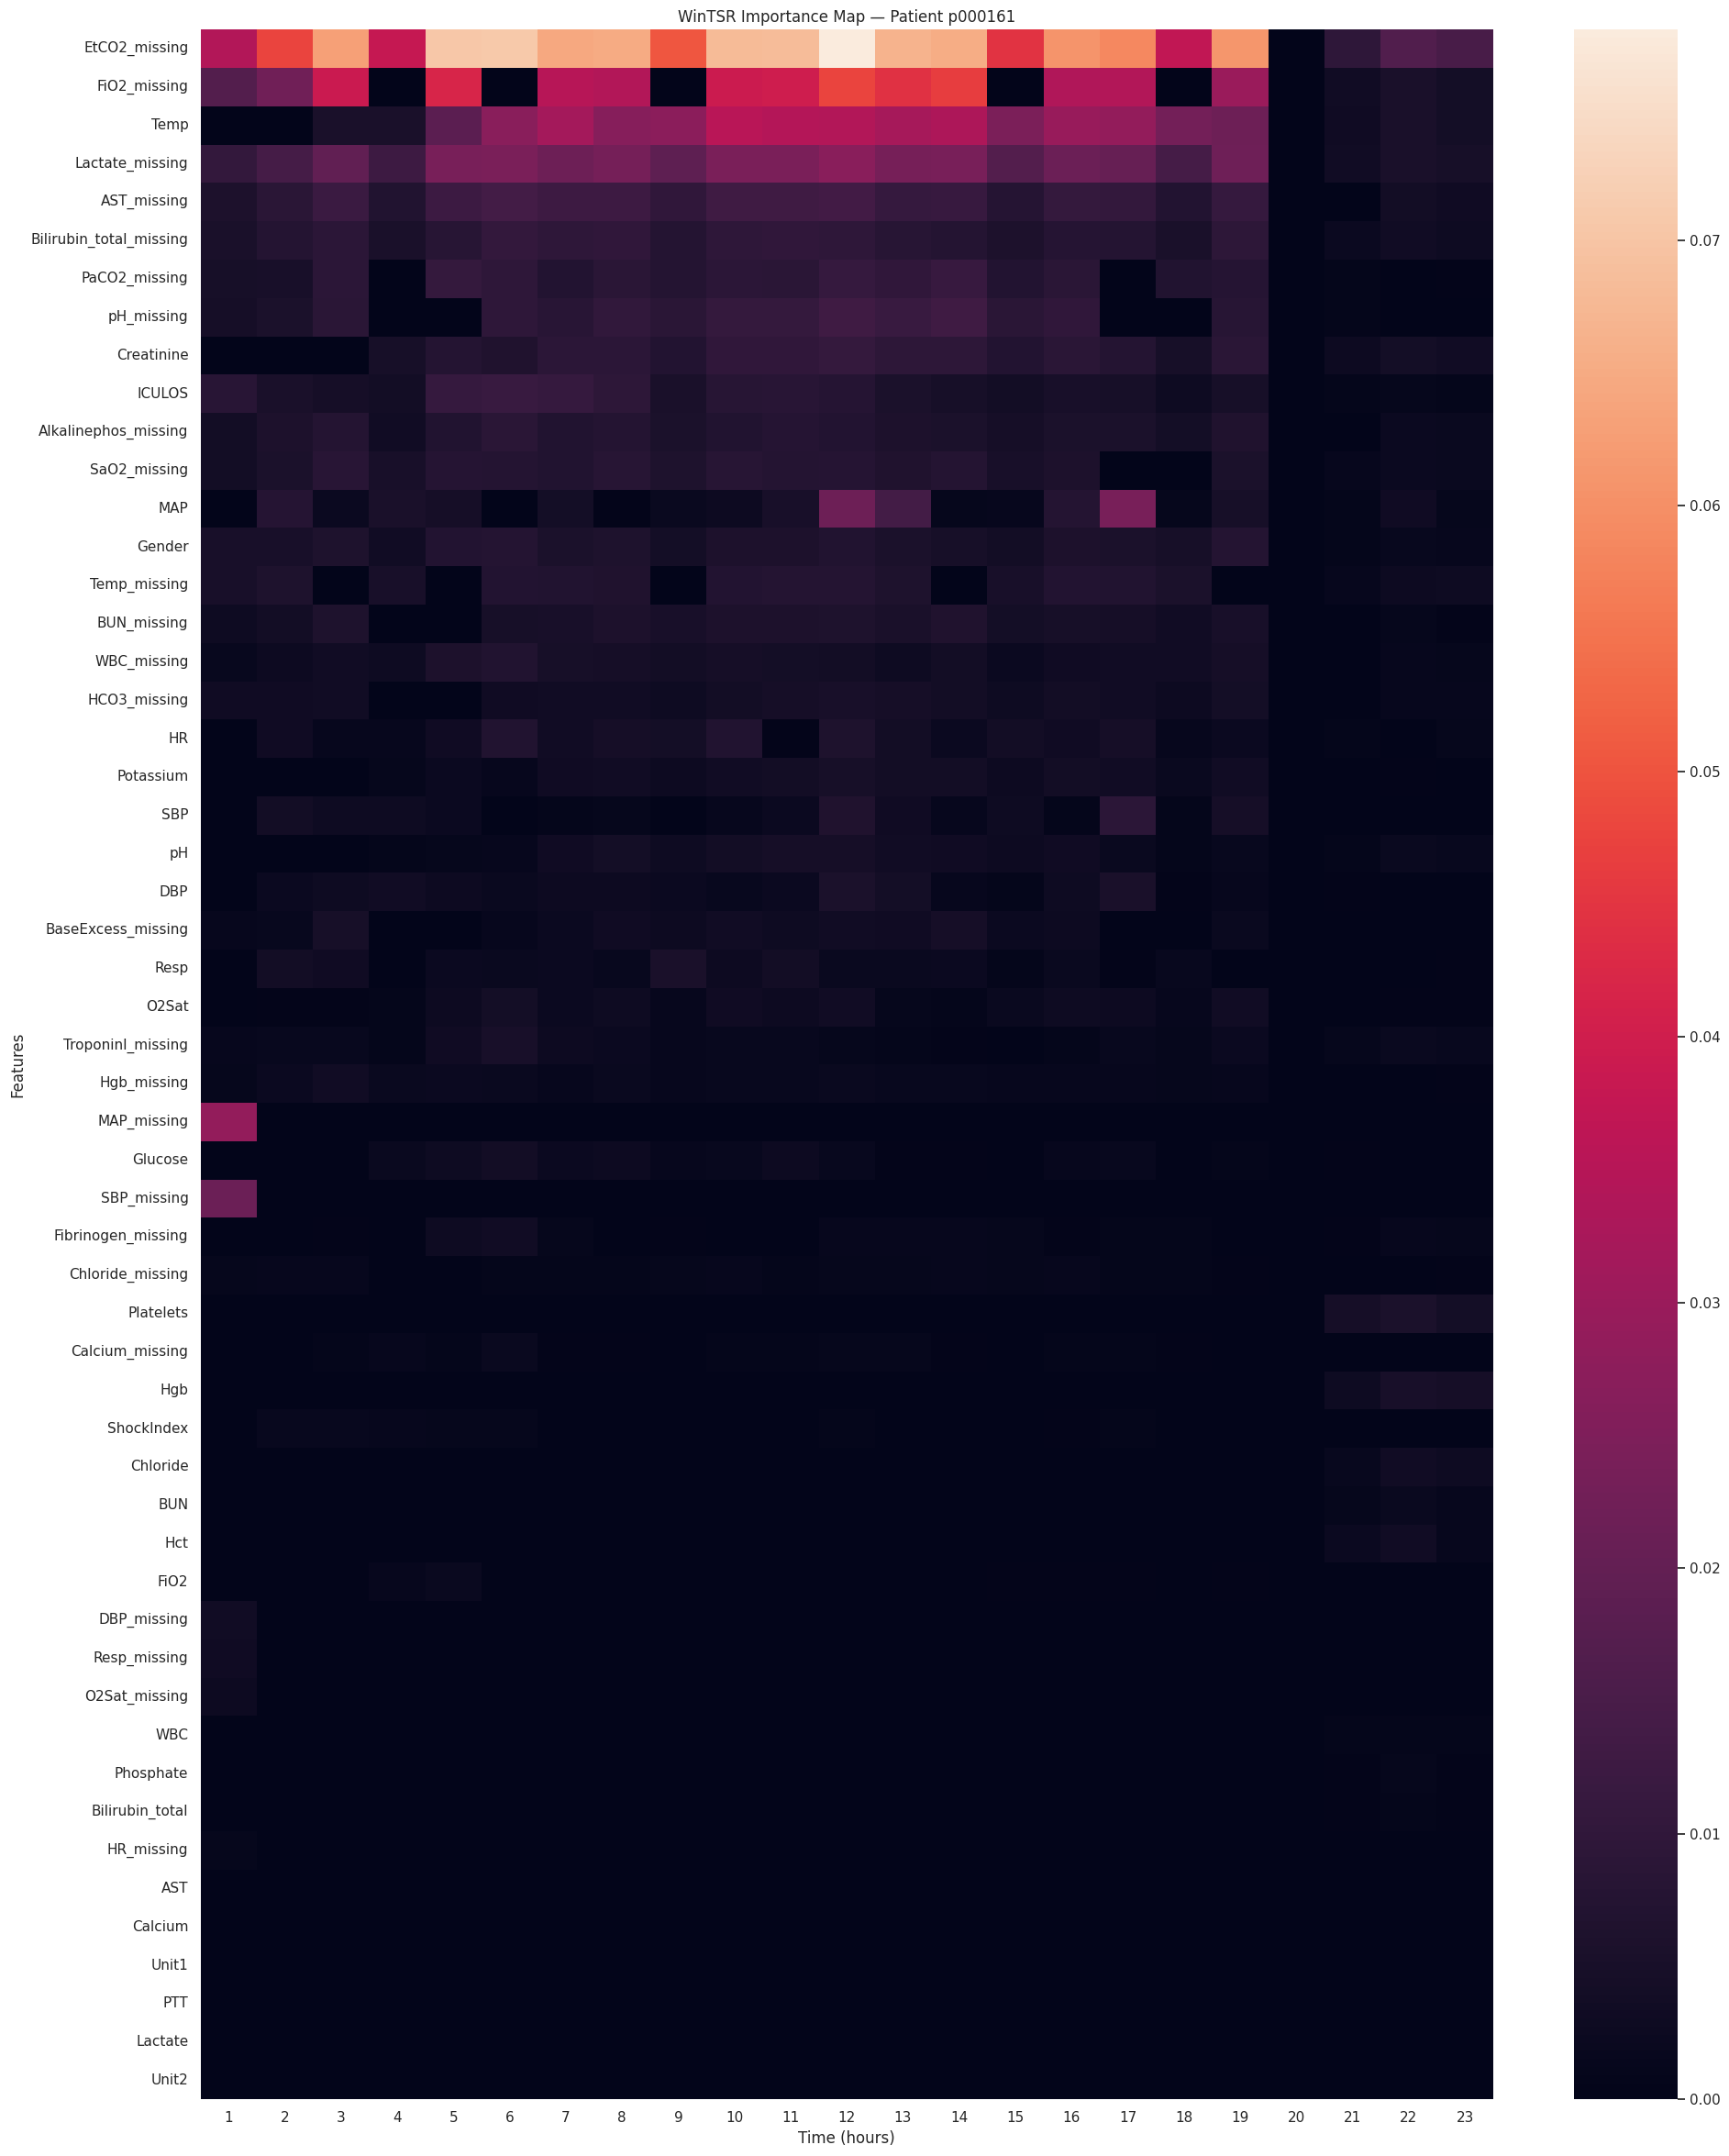

In [40]:
plot_wintsr(importance_map, df_col, patient_id='p000161', filename='wintsr_heatmap_p000161_all_features.svg')

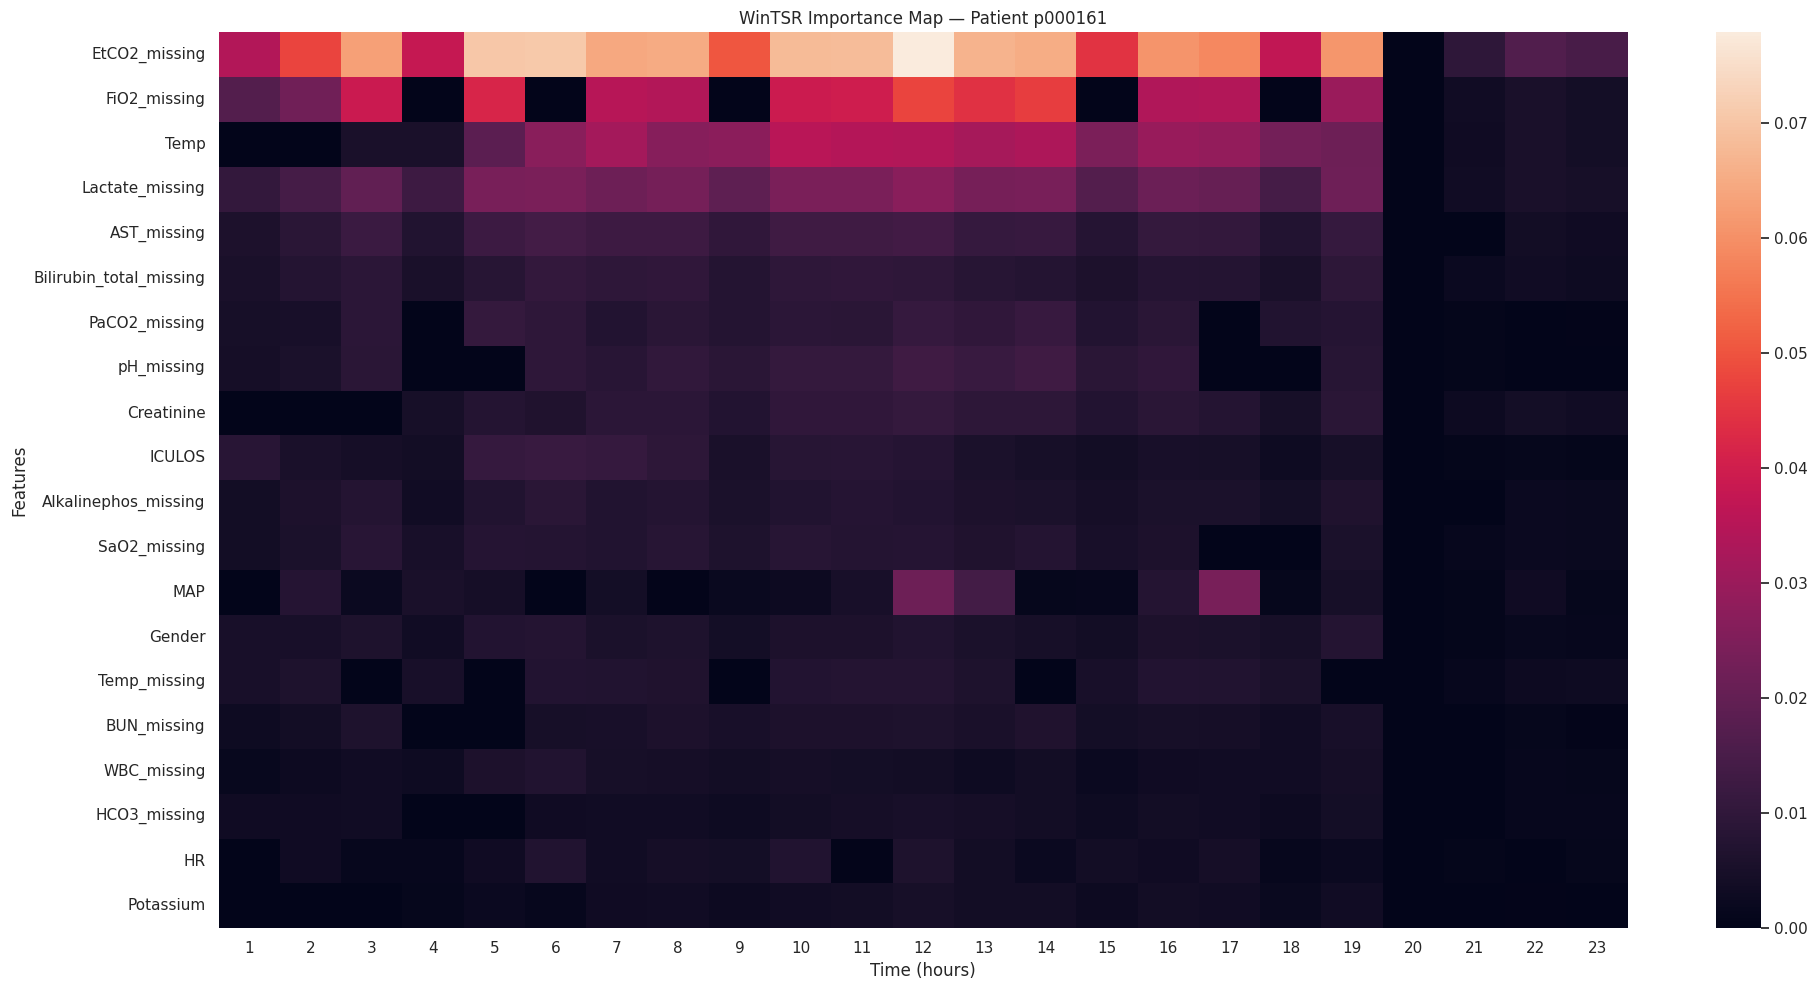

In [41]:
plot_wintsr(importance_map, df_col, patient_id='p000161', top_k=20, filename='wintsr_heatmap_p000161_top_20.svg')

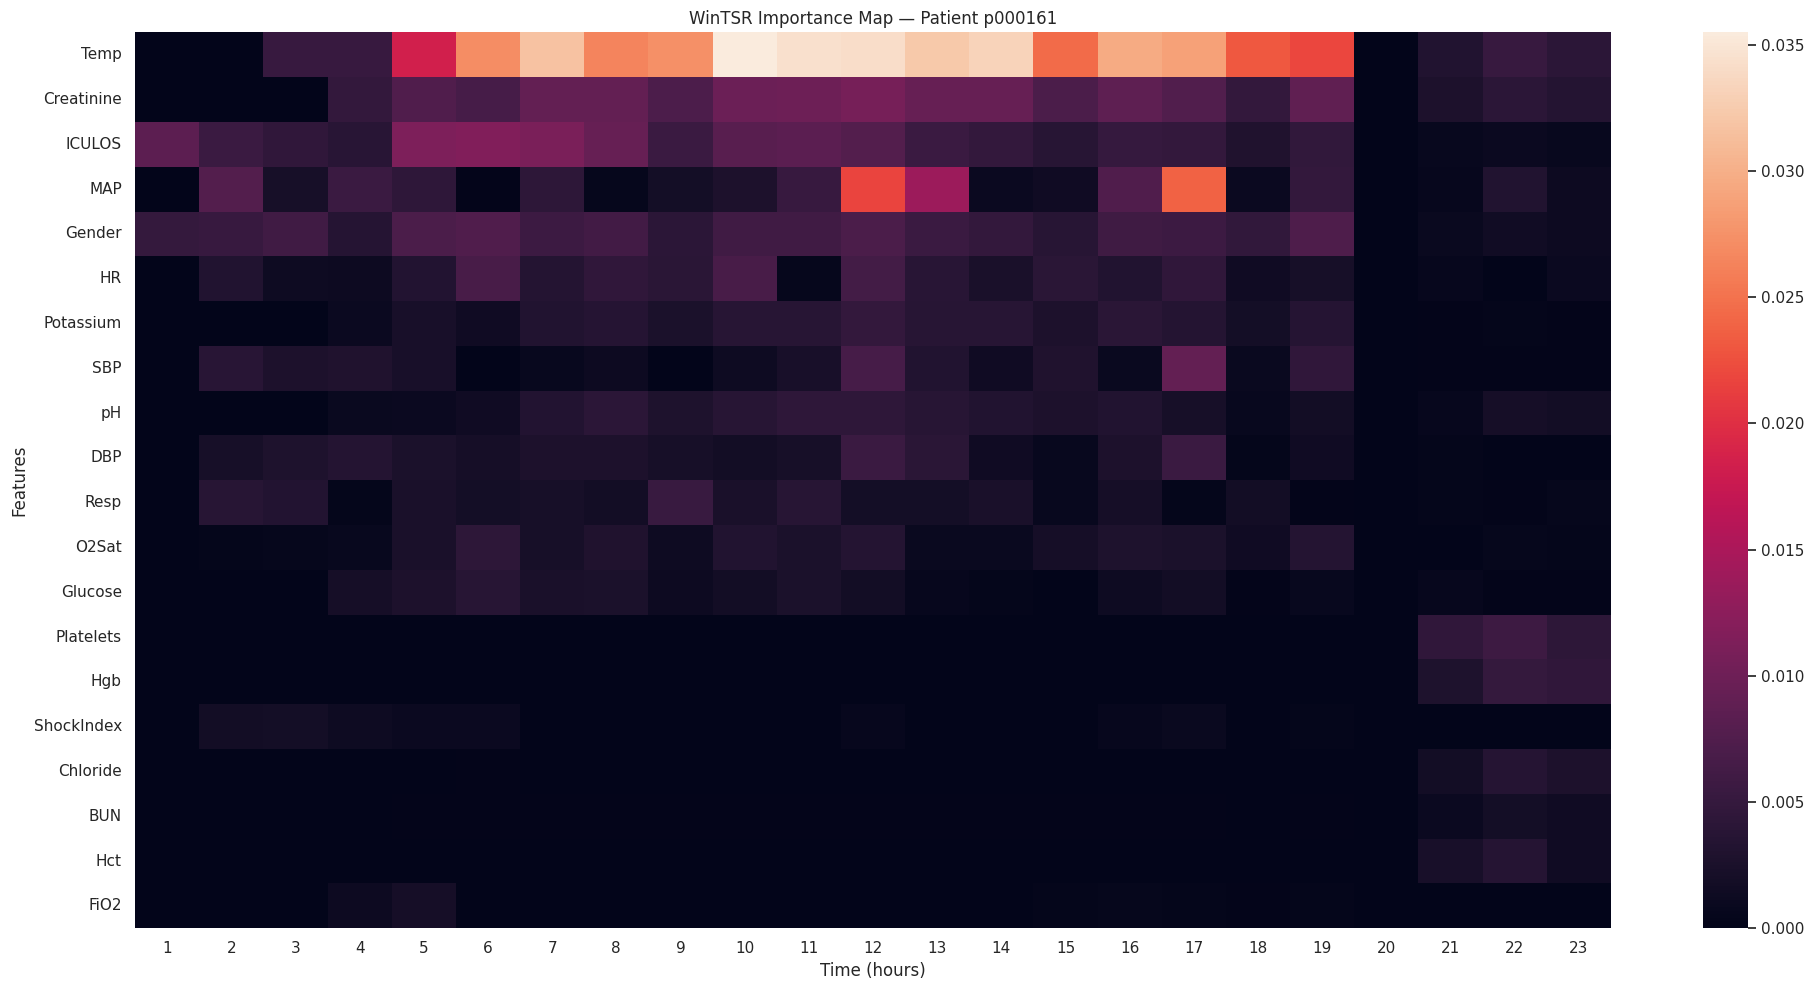

In [42]:
plot_wintsr(importance_map, df_col, patient_id='p000161', top_k=20, show_missing=False, filename='wintsr_heatmap_p000161_top_20_original_features.svg')

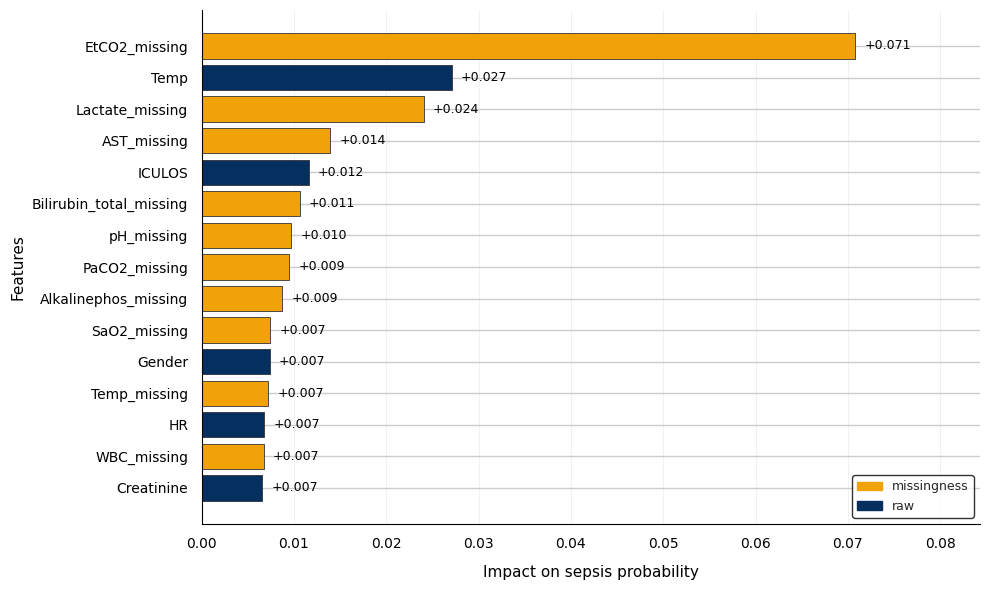

In [58]:
plot_wintsr_bar(importance_map, df_col, hour=6, color_func=get_color_v1, colors_dict=colors_v1,patient_id='p000161', filename='wintsr_bar_p000161_hour6.svg')

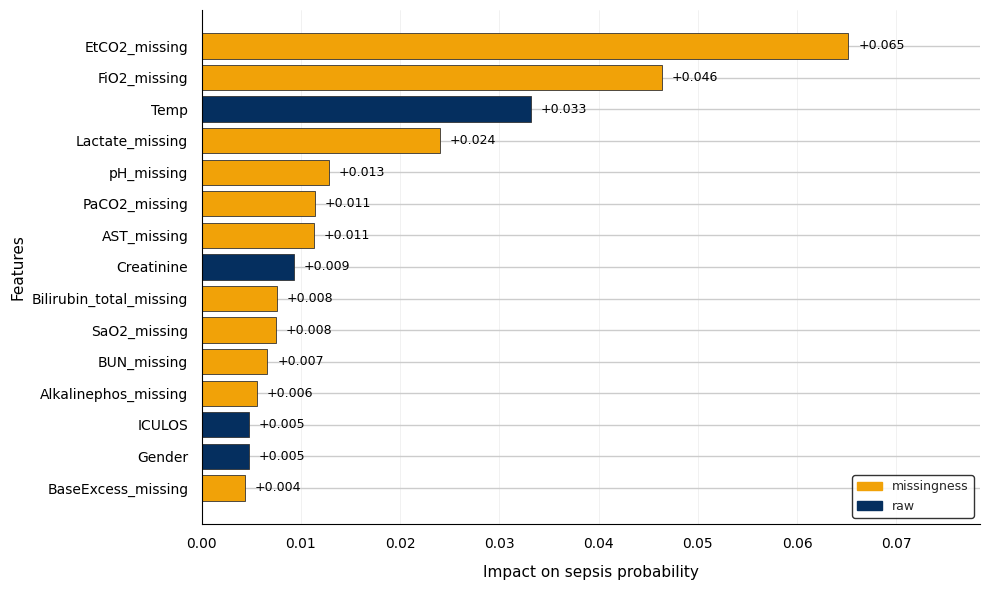

In [59]:
plot_wintsr_bar(importance_map, df_col, hour=14, color_func=get_color_v1, colors_dict=colors_v1, patient_id='p000161', filename='wintsr_bar_p000161_hour14.svg')

## Non-septic patient p000001

In [60]:
importance_map_non_septic, feature_relevance_non_septic, time_relevance_non_septic = wintsr(
    model_tcn, patient_non_septic_features, device
)

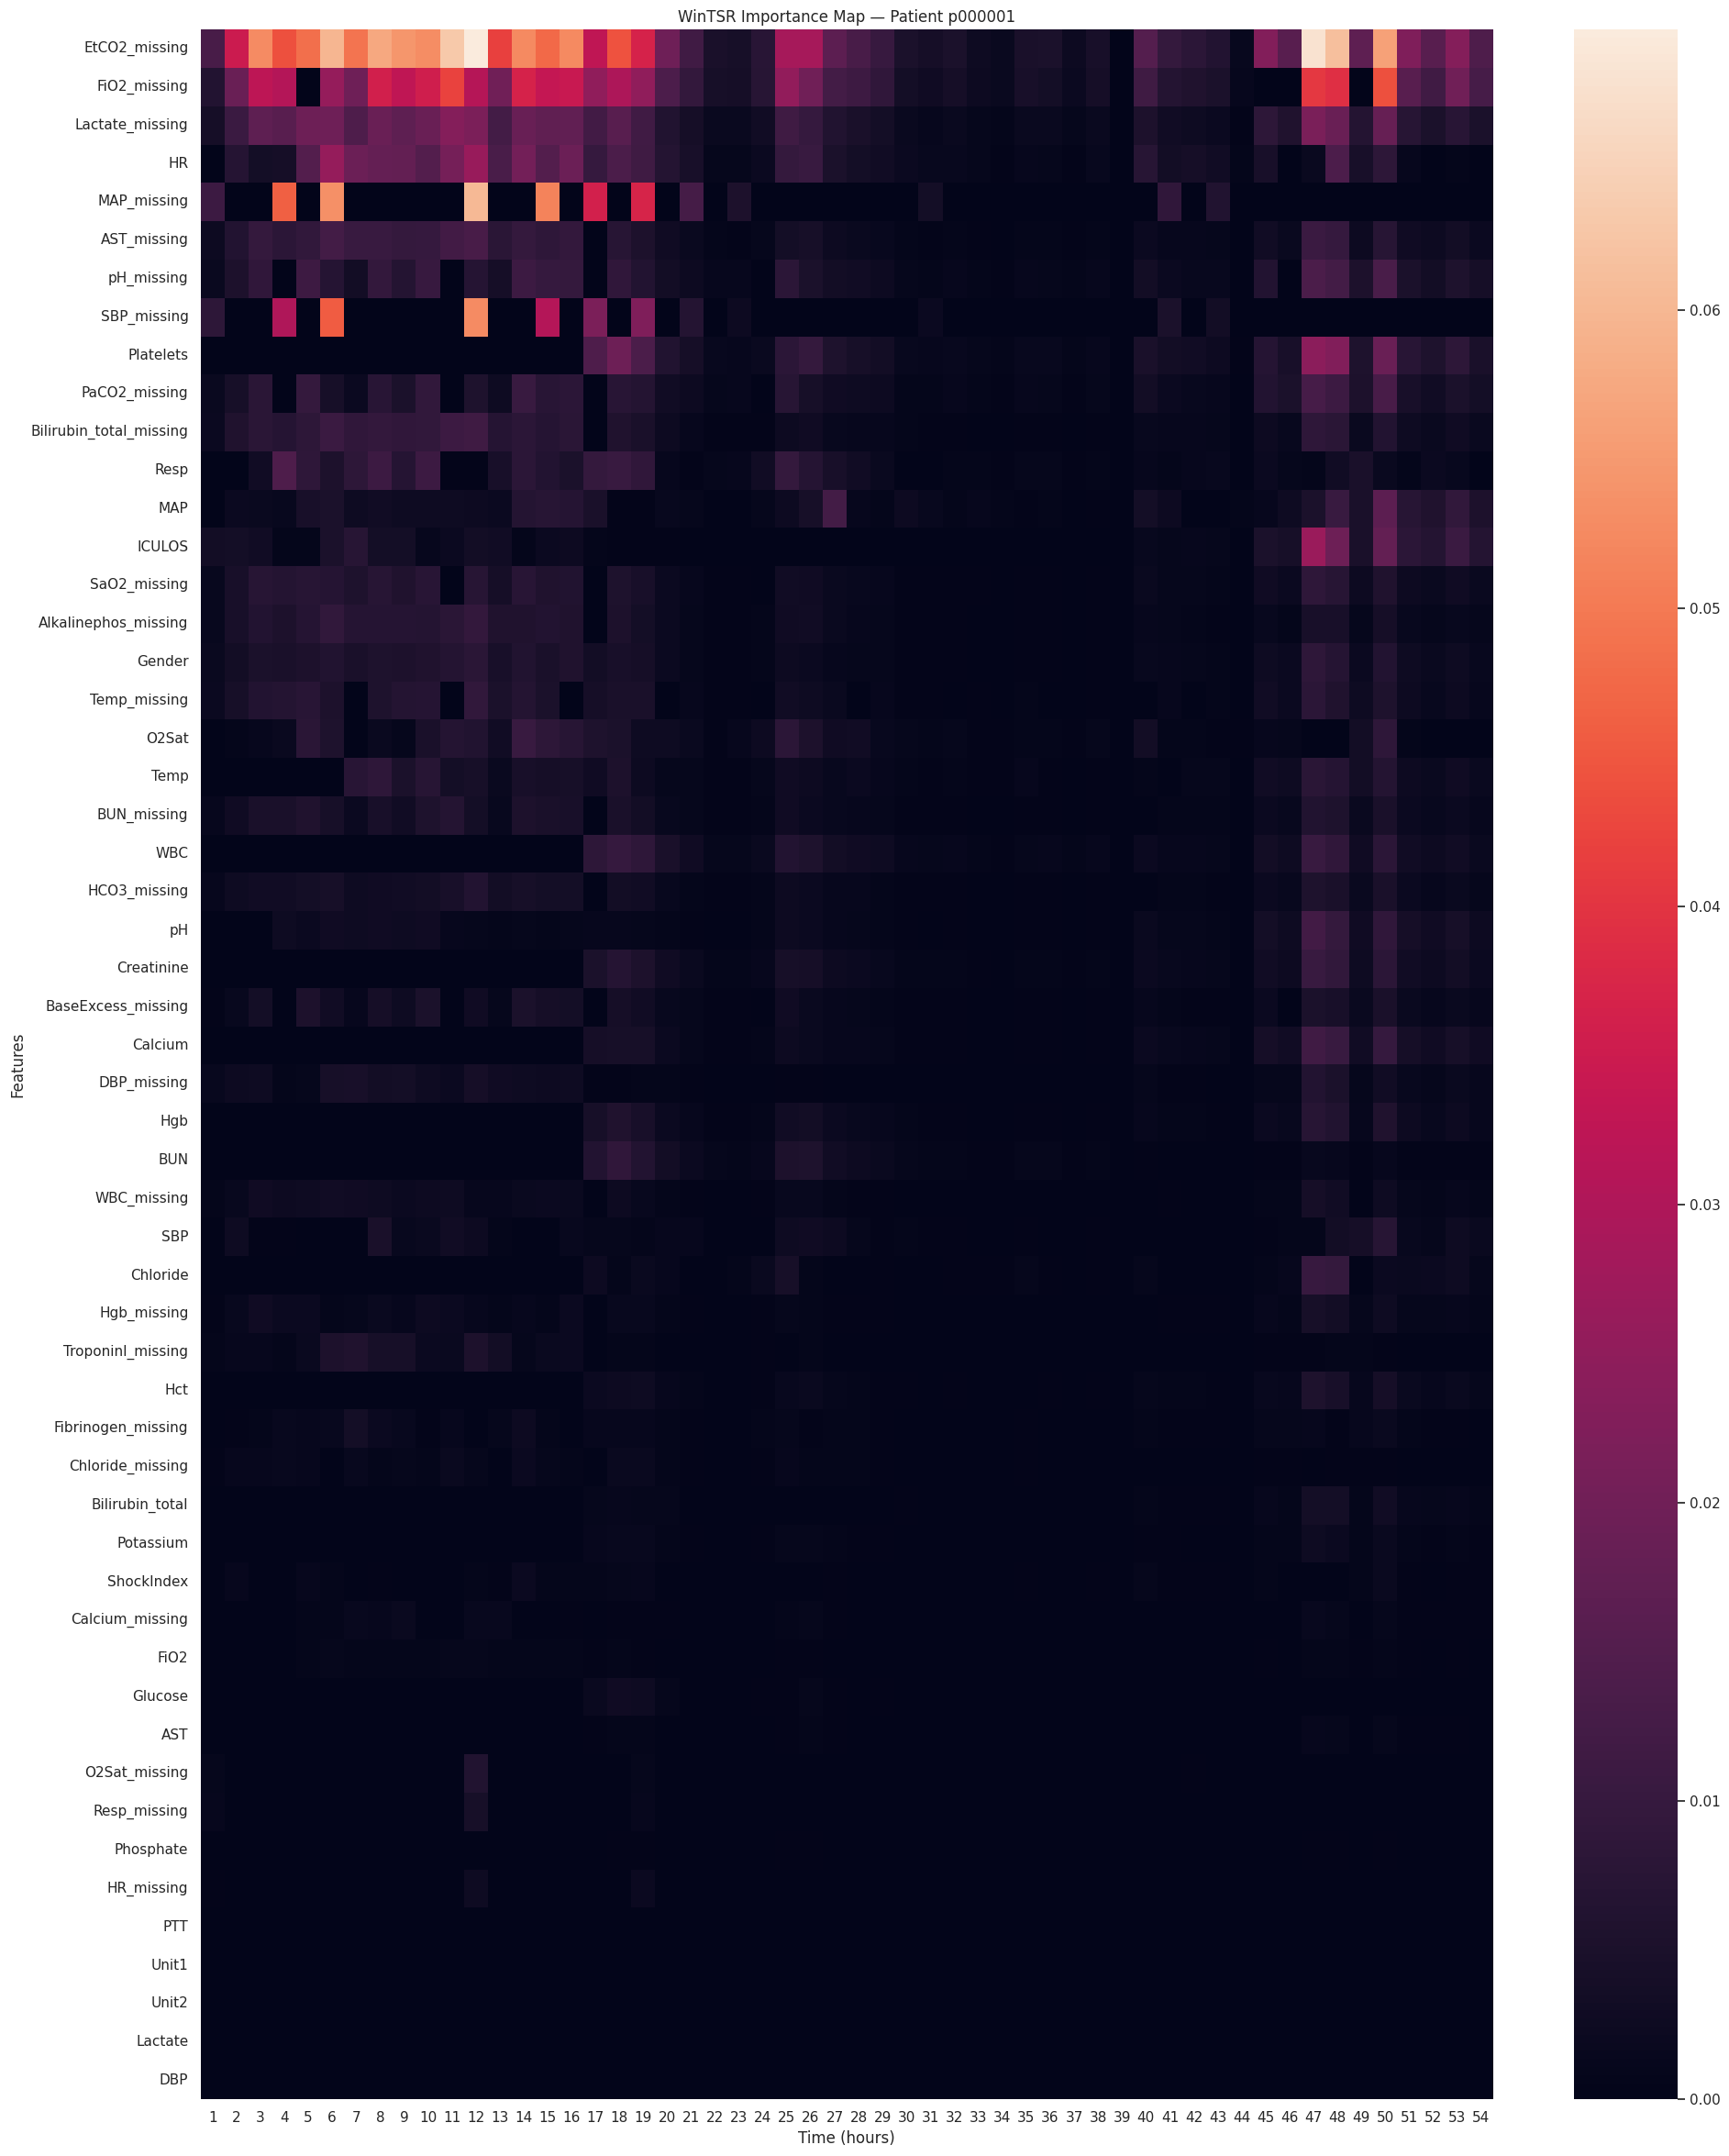

In [61]:
plot_wintsr(importance_map_non_septic, df_col, patient_id='p000001', filename='wintsr_heatmap_p000001_all_features.svg')

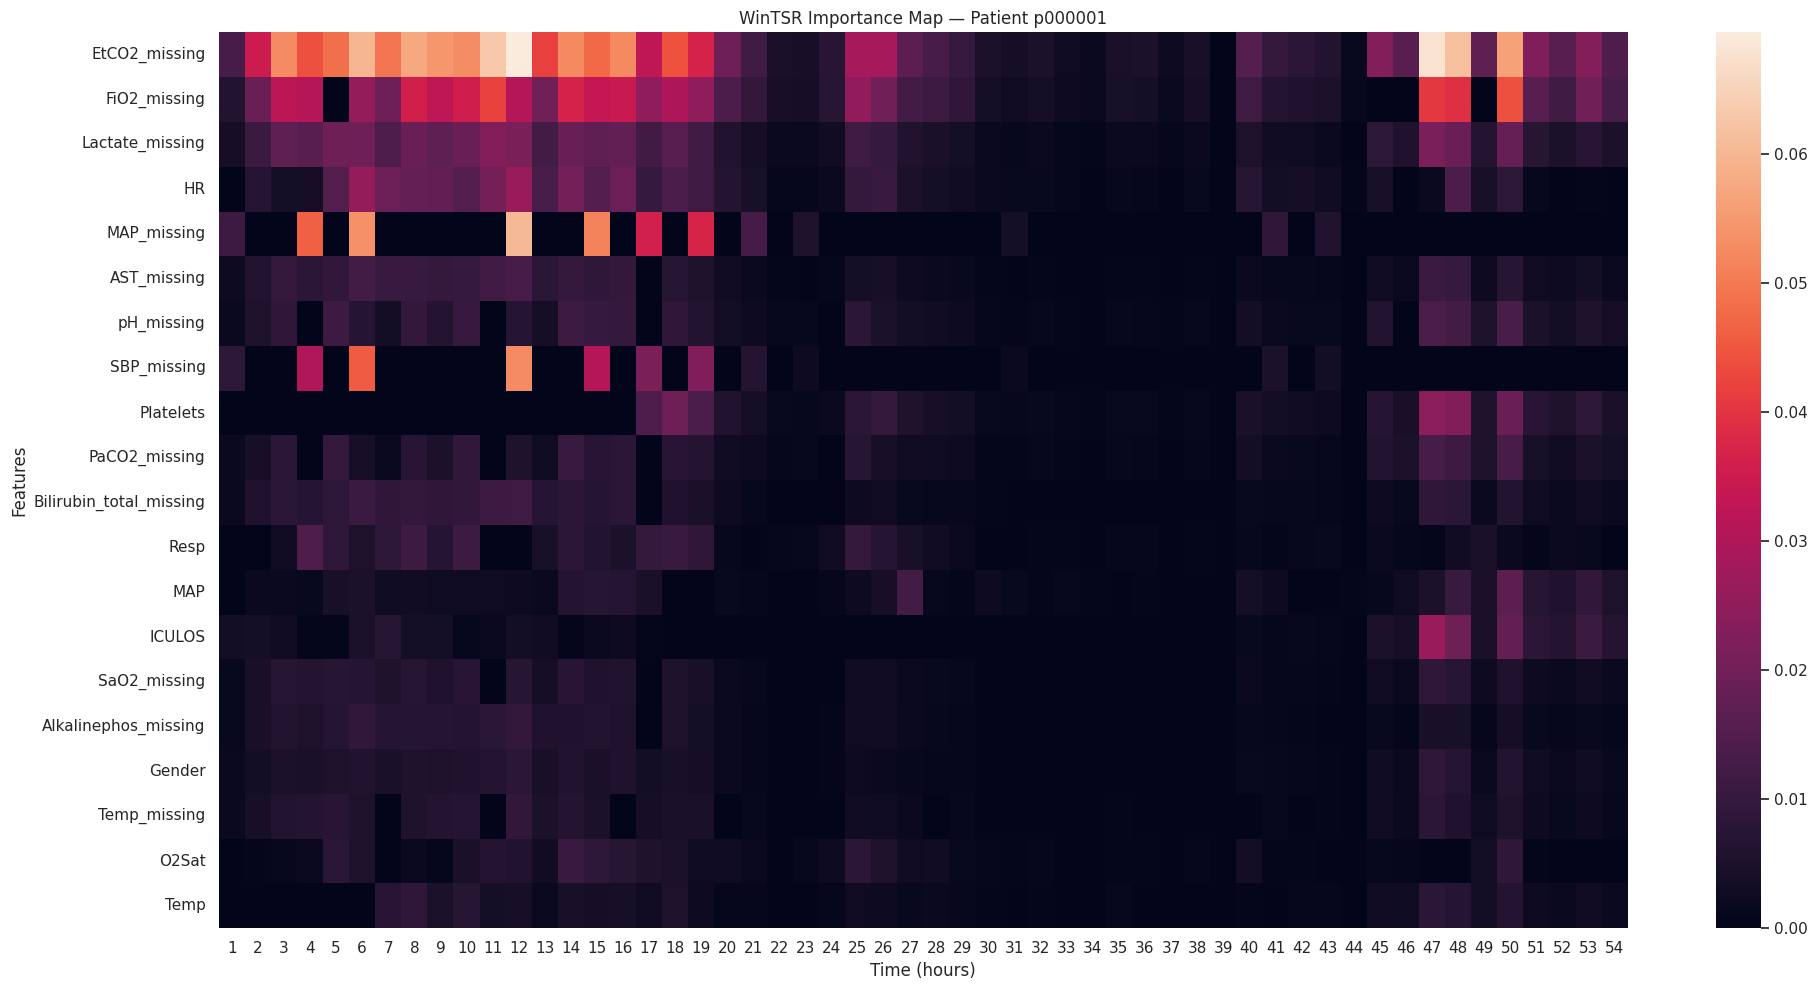

In [62]:
plot_wintsr(importance_map_non_septic, df_col, patient_id='p000001', top_k=20, filename='wintsr_heatmap_p000001_top_20.svg')

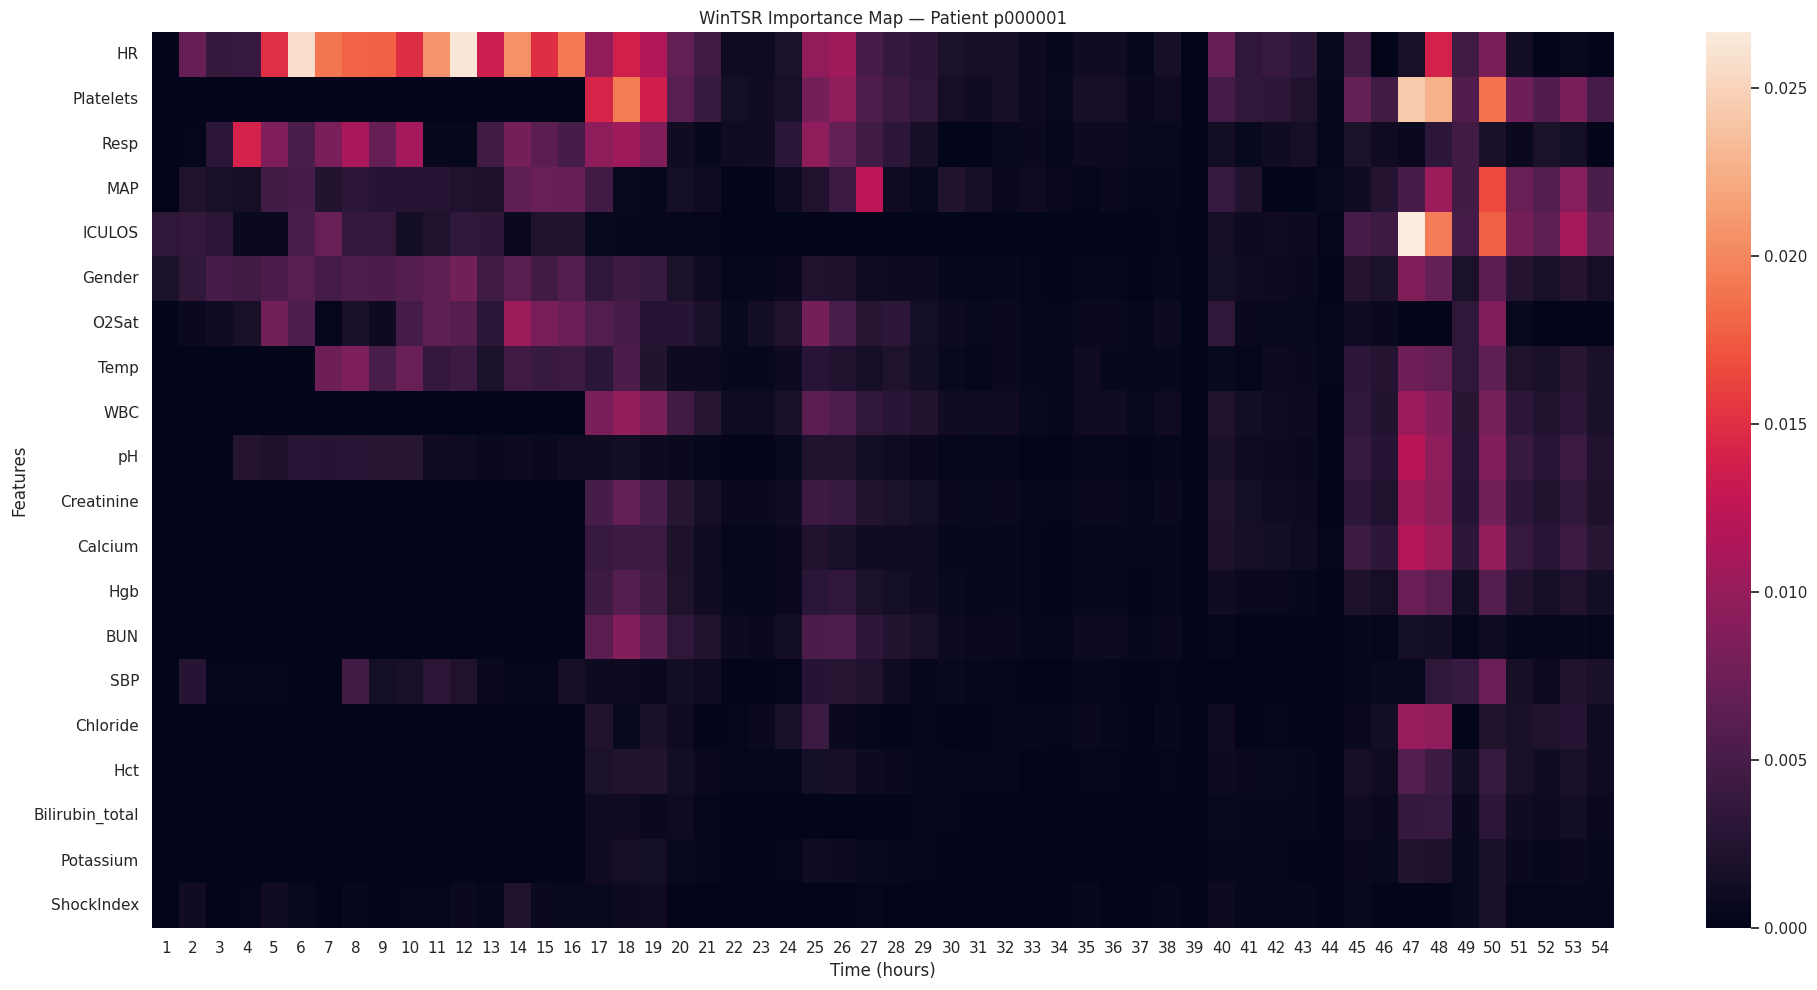

In [63]:
plot_wintsr(importance_map_non_septic, df_col, patient_id='p000001', top_k=20, show_missing=False, filename='wintsr_heatmap_p000001_top_20_original_features.svg')

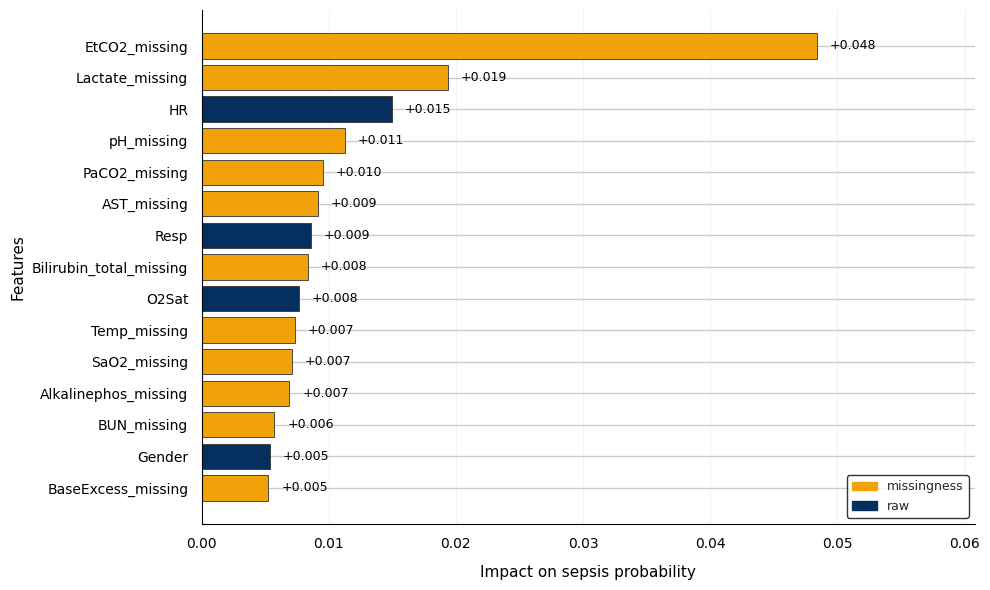

In [64]:
plot_wintsr_bar(importance_map_non_septic, df_col, hour=5, color_func=get_color_v1, colors_dict=colors_v1, patient_id='p000001', filename='wintsr_bar_p000001_hour5.svg')

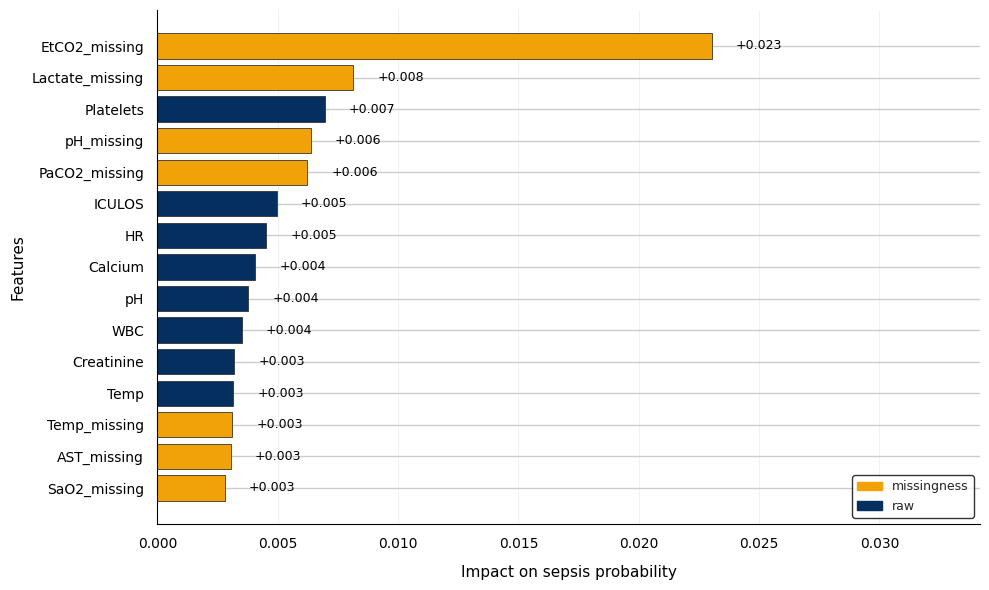

In [65]:
plot_wintsr_bar(importance_map_non_septic, df_col, hour=45, color_func=get_color_v1, colors_dict=colors_v1, patient_id='p000001', filename='wintsr_bar_p000001_hour45.svg')